# Project

Library install and import

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import root_mean_squared_error

In [2]:
# to ensure reproductiability
seed = 42

In [3]:
from pathlib import Path
import sys
import os

# path
PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name != "src" else Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.ctgan_utils import seed_everything
from src.ctgan_eval import evaluate_and_merge, qc_univariate, correlation_chart, kernel_chart, kernel_chart_total
from src.modeling import concat_dataframe, metrics, run_experiment, cv5, plot_overbreak_comparison

In [4]:
# Load the best models
from sdv.single_table import CTGANSynthesizer
model_c0 = CTGANSynthesizer.load(PROJECT_ROOT/'2_CGTAN/ctgan_tuning/c0/best_model/ctgan_model.zip')
model_c1 = CTGANSynthesizer.load(PROJECT_ROOT/'2_CGTAN/ctgan_tuning/c1/best_model/ctgan_model.zip')

C:\Users\llame\AppData\Local\Programs\Python\Python312\Lib\site-packages\sdv\_utils.py:500: FutureWarning:

The 'load' function will be deprecated in future versions of SDV. Please use 'utils.load_synthesizer' instead.

C:\Users\llame\AppData\Local\Programs\Python\Python312\Lib\site-packages\sdv\_utils.py:500: FutureWarning:

The 'load' function will be deprecated in future versions of SDV. Please use 'utils.load_synthesizer' instead.



### Reported data

In [5]:
df_t3 = pd.read_excel(PROJECT_ROOT/'0_Data/paper.xlsx', sheet_name='table3')
df_t3["Δmean_%"] =  100.0 * abs(df_t3["mean_df_syn"] - df_t3["mean_df_real"] ) / abs(df_t3["mean_df_real"] )
df_t3["Δstd_%"] =  100.0 * abs(df_t3["std_df_syn"] - df_t3["std_df_real"] ) / abs(df_t3["std_df_real"] )
df_t3

,variable,min_df_real,min_df_syn,max_df_real,max_df_syn,mean_df_real,mean_df_syn,std_df_real,std_df_syn,Δmean_%,Δstd_%
0,UCS (Mpa),32.6,32.6,49.3,49.3,38.109,38.415,4.410,4.866,0.802960,10.340136
1,RD (g/cm3),2.3,2.3,2.8,2.8,2.576,2.563,0.118,0.130,0.504658,10.169492
2,TC (kg),216.0,216.0,318.0,318.0,257.900,262.532,31.824,34.729,1.796045,9.128331
3,W (cm),30.0,30.0,80.0,80.0,66.244,66.618,9.180,10.081,0.564579,9.814815
4,CS (cm),50.0,50.0,120.0,120.0,81.633,84.052,13.287,14.685,2.963262,10.521562
5,E (cm),47.0,47.0,85.0,85.0,67.168,67.657,9.400,10.376,0.728025,10.382979
6,OB (cm),15.1,15.1,30.9,30.9,23.911,23.709,3.828,3.738,0.844799,2.351097


In [6]:
df_t5 = pd.read_excel(PROJECT_ROOT/'0_Data/paper.xlsx', sheet_name='table5')
df_t6 = pd.read_excel(PROJECT_ROOT/'0_Data/paper.xlsx', sheet_name='table6')

### Best CTGAN parameters

In [8]:
# CGTAN parameters to train
params_c0 = {
    # fixed as paper
    "batch_size": 200,    "generator_dim": (256, 256),
    "discriminator_dim": (256, 256),
    "generator_lr": 2e-4,
    "discriminator_lr": 2e-4,
    "generator_decay": 1e-6,
    "discriminator_decay": 1e-6,
    "enforce_rounding": True,
    "enforce_min_max_values": True,
    # loop
    "pac": 10,
    "epochs": 1000,
}

params_c1 = {
    # fixed as paper
    "batch_size": 200,
    "generator_dim": (256, 256),
    "discriminator_dim": (256, 256),
    "generator_lr": 2e-4,
    "discriminator_lr": 2e-4,
    "generator_decay": 1e-6,
    "discriminator_decay": 1e-6,
    "enforce_rounding": True,
    "enforce_min_max_values": True,
    # loop
    "pac": 8,
    "epochs": 1500,
}

## Exp: 1

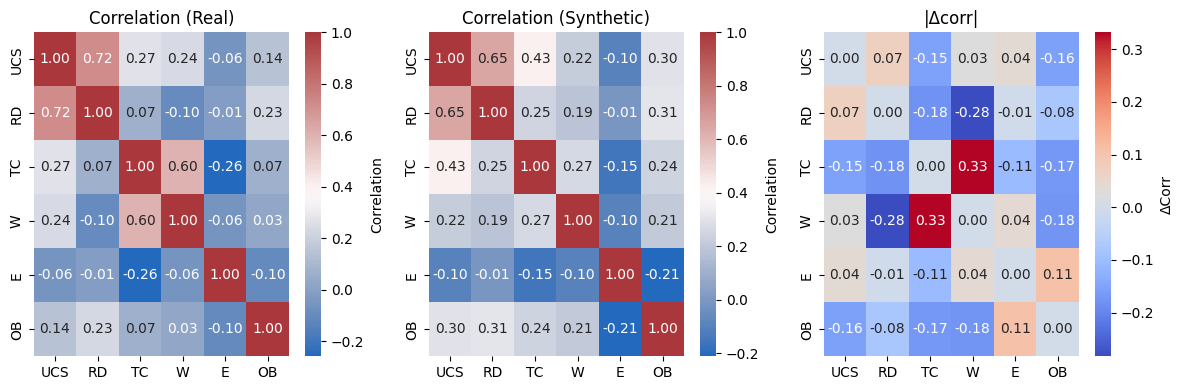

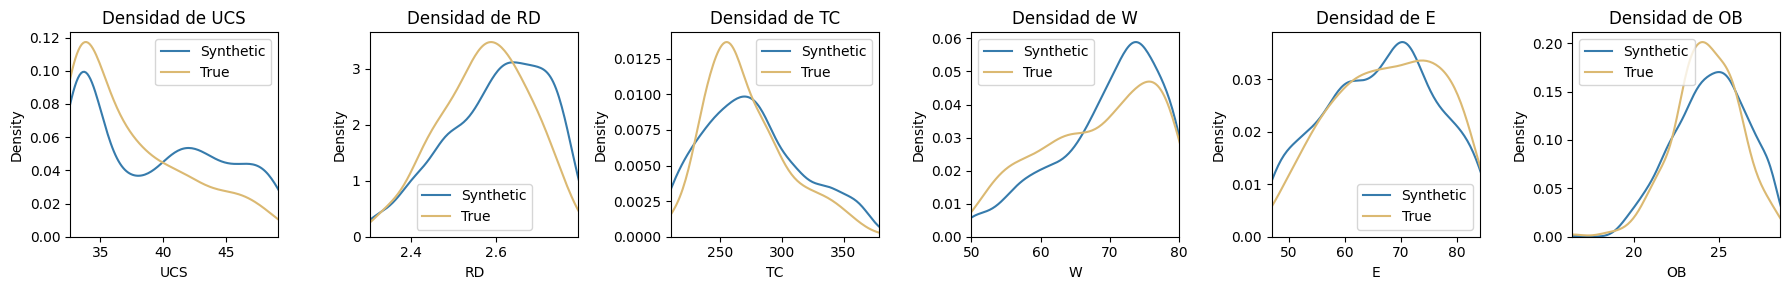

In [9]:
# Real data
df_c0_train = pd.read_csv(PROJECT_ROOT/'1_Clustering'/'1_cluster0.csv')
df_c1_train = pd.read_csv(PROJECT_ROOT/'1_Clustering'/'1_cluster1.csv')
df_test = pd.read_csv(PROJECT_ROOT/'1_Clustering'/'1_test.csv')

# Synthetic data
new_c0_exp1 = pd.read_csv(PROJECT_ROOT/'2_CGTAN/ctgan_tuning/c0/best_model/exp1'/'synthetic_exp1.csv')
new_c1_exp1 = pd.read_csv(PROJECT_ROOT/'2_CGTAN/ctgan_tuning/c1/best_model/exp1'/'synthetic_exp1.csv')

# Hybrid data
df_real_train_exp1, df_synthetic_train_exp1, df_hybrid_train_exp1 = concat_dataframe(df_c0_train= df_c0_train, 
                                                                                     df_c1_train= df_c1_train, 
                                                                                     df_c0_synthetic= new_c0_exp1, 
                                                                                     df_c1_synthetic= new_c1_exp1)

# Save
out_dir_exp1 = "3_Sample/exp1"
evaluate_and_merge(df_real_train_exp1, df_synthetic_train_exp1, out_dir_exp1)

path_exp1 = os.path.join(out_dir_exp1, "hybrid_exp1.csv")
df_hybrid_train_exp1.to_csv(path_exp1, index=False)

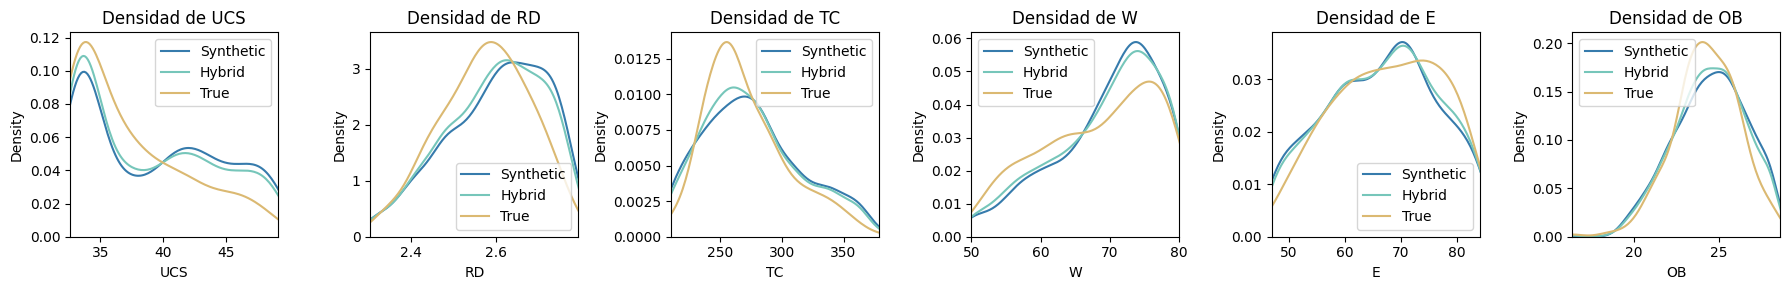

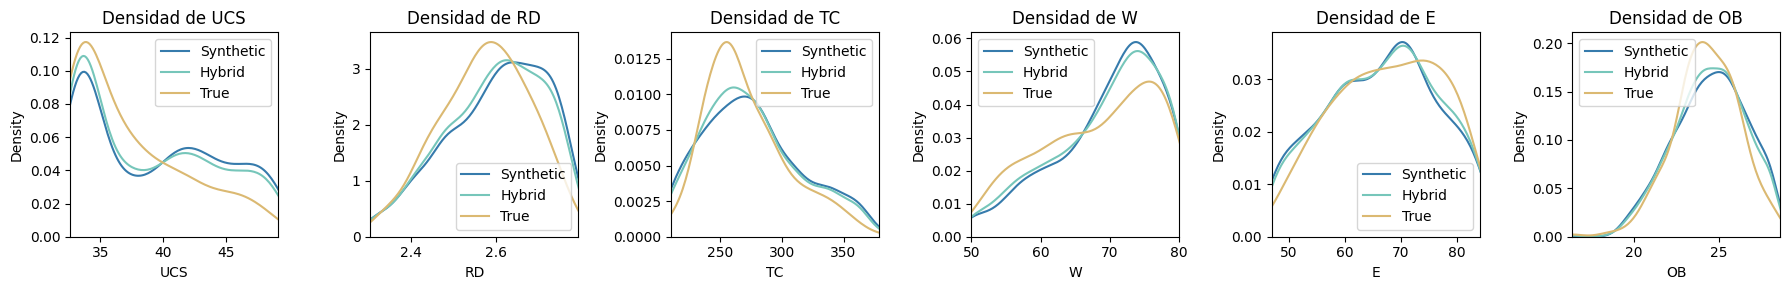

In [15]:
kernel_chart_total(df_real_train_exp1, df_synthetic_train_exp1, df_hybrid_train_exp1)

In [16]:
qc_univariate(df_real_train_exp1, df_synthetic_train_exp1) 

,variable,KS_stat,KS_p,min_df_real,min_df_syn,max_df_real,max_df_syn,mean_df_real,mean_df_syn,std_df_real,std_df_syn,Δmean_%,Δstd_%
4,E,0.074283,1.625759e-01,47.000000,47.000000,84.000000,84.000000,67.693662,66.350688,9.519619,9.943390,1.983900,4.451554
5,OB,0.100079,2.154368e-02,16.344658,16.344658,28.626925,28.626925,24.281126,24.520066,1.928237,2.140093,0.984057,10.987036
1,RD,0.154473,4.265272e-05,2.304505,2.304505,2.795202,2.795202,2.574801,2.603445,0.106088,0.117944,1.112450,11.175287
2,TC,0.113873,5.722591e-03,210.361040,210.361040,378.446298,378.446298,271.747067,276.833197,33.672233,40.483238,1.871641,20.227364
0,UCS,0.197515,4.586346e-08,32.600449,32.600449,49.126658,49.126658,37.436299,39.360087,4.565022,5.433468,5.138831,19.023900
3,W,0.114163,5.554057e-03,50.000000,50.000000,80.000000,80.000000,68.348592,69.752456,8.326485,7.541274,2.053977,9.430280


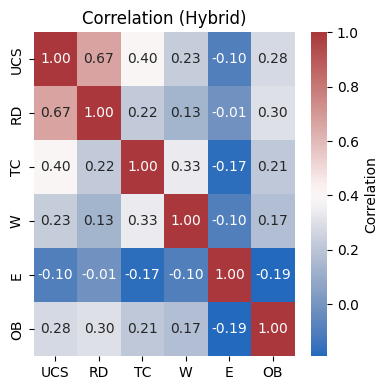

In [17]:
corr_matrix = df_hybrid_train_exp1.corr()

fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='vlag', cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation (Hybrid)')

output_path = os.path.join(out_dir_exp1, "corr_hyb.png")
plt.savefig(output_path)

plt.tight_layout()
plt.show()

#### Overbreak predictions
- With training data (real): train XGBoost, RF, DNN (with funnel shape)
- With hybrid data: train DA-XGB
- With test data (real), calculate metrics: R², RMSE, MAE, MAPE and compare
- GridDearch to optimize the parameters, using R2 as a score.
- Calculate k-fold temporal

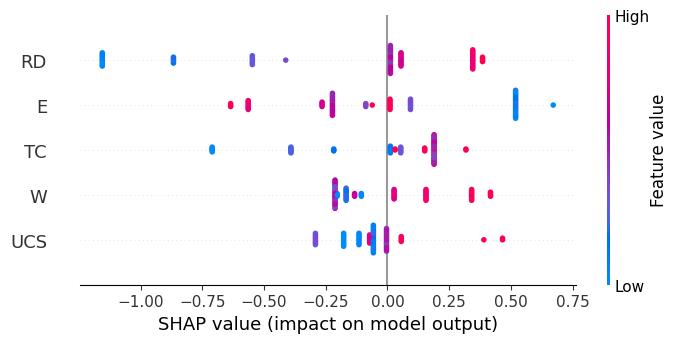

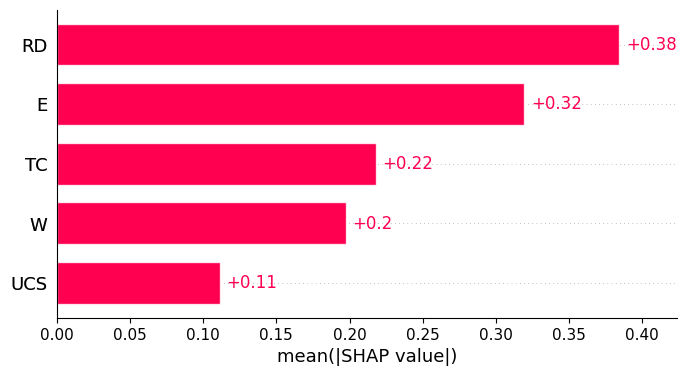

,DA-XGB,XGB,RF,DNN
R2,0.283,0.859,0.729,0.620
RMSE,1.917,0.849,1.179,1.396
MAE,1.480,0.613,0.801,0.965
MAPE,0.063,0.027,0.035,0.042


In [18]:
df_kpi_exp1, best_params_exp1, preds_exp1, shap_rank_exp1 = run_experiment(df_train = df_real_train_exp1, 
                                                           df_test = df_test, 
                                                           df_hybrid_train = df_hybrid_train_exp1,
                                                           seed = seed
                                                          )

df_kpi_exp1

In [19]:
best_params_exp1

{'DA-XGB': {'max_depth': 1, 'min_child_weight': 10, 'n_estimators': 100},
 'XGB': {'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200},
 'RF': {'max_depth': 10, 'n_estimators': 300},
 'DNN': {'dnn__activation': 'relu',
  'dnn__batch_size': 16,
  'dnn__hidden_layer_sizes': (256, 128),
  'dnn__max_iter': 190}}

In [20]:
shap_rank_exp1

,feature,mean_abs_shap
1,RD,0.384306
4,E,0.319469
2,TC,0.217767
3,W,0.197609
0,UCS,0.111491


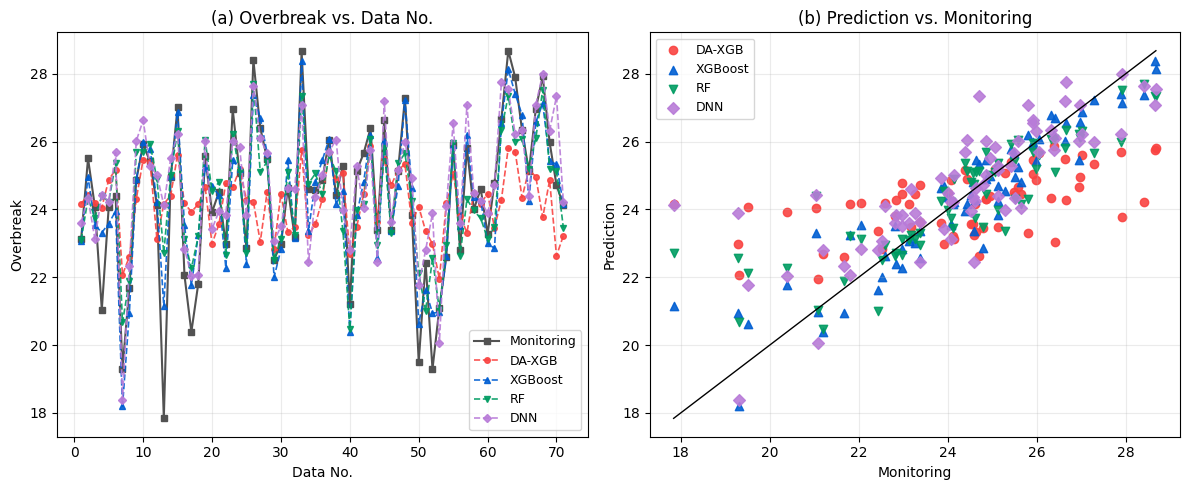

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': '(a) Overbreak vs. Data No.'}, xlabel='Data No.', ylabel='Overbreak'>,
        <Axes: title={'center': '(b) Prediction vs. Monitoring'}, xlabel='Monitoring', ylabel='Prediction'>],
       dtype=object))

In [21]:
plot_overbreak_comparison(df_test = df_test, preds_dict= preds_exp1)

In [22]:
# Considering the total data generated in exp2
x_exp1 = 509

# Cross validation
cv_exp1 = cv5(df_train= df_real_train_exp1,
    best_params = best_params_exp1,
    best_params_model_c0 = params_c0, 
    best_params_model_c1 = params_c1, 
    n0_sample=x_exp1, 
    n1_sample=x_exp1, 
    seed=seed)

C:\Users\llame\AppData\Local\Programs\Python\Python312\Lib\site-packages\sdv\single_table\base.py:168: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

C:\Users\llame\AppData\Local\Programs\Python\Python312\Lib\site-packages\sdv\single_table\base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.

C:\Users\llame\AppData\Local\Programs\Python\Python312\Lib\site-packages\ctgan\synthesizers\_utils.py:16: FutureWarning:

`cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.

Gen. (-1.53) | Discrim. (0.08): 100%|██████████████████████████████████████████████| 1000/1000 [00:20<00:00, 47.92it/s]
C:\Users\llame\AppData\Local\Programs\Python\Python312\Lib\site-packages\sdv\single_table\base.py:168: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.


In [23]:
cv_exp1 

,R2_mean,R2_std,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MAPE_mean,MAPE_std
Model,,,,,,,,
XGB,0.761,0.069,0.916,0.061,0.671,0.035,0.029,0.001
RF,0.638,0.072,1.135,0.076,0.850,0.058,0.036,0.003
DNN,0.528,0.123,1.290,0.057,1.017,0.056,0.043,0.002
DA-XGB,0.424,0.130,1.433,0.140,1.076,0.081,0.046,0.004


## Exp 2

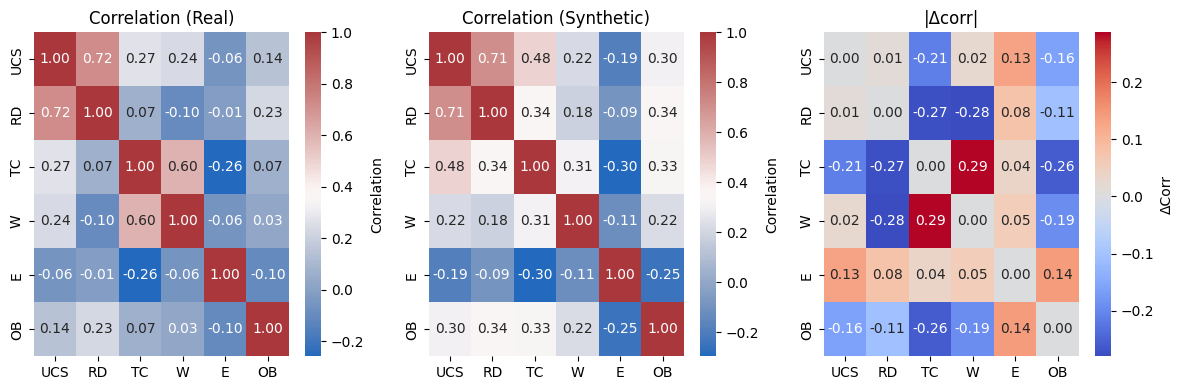

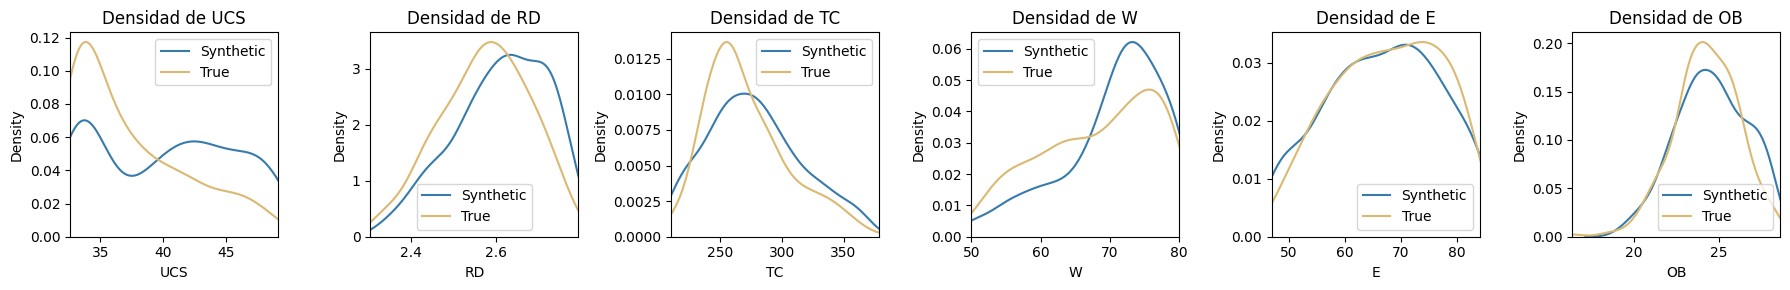

In [24]:
# Real data the same as Exp2

# Synthetic data
new_c0_exp2 = pd.read_csv(PROJECT_ROOT/'2_CGTAN/ctgan_tuning/c0/best_model/exp2'/'synthetic_exp2.csv')
new_c1_exp2 = pd.read_csv(PROJECT_ROOT/'2_CGTAN/ctgan_tuning/c1/best_model/exp2'/'synthetic_exp2.csv')

# Hybrid data
df_real_train_exp2, df_synthetic_train_exp2, df_hybrid_train_exp2 = concat_dataframe(df_c0_train= df_c0_train, 
                                                                                     df_c1_train= df_c1_train,
                                                                                     df_c0_synthetic= new_c0_exp2, 
                                                                                     df_c1_synthetic= new_c1_exp2)

# Save
out_dir_exp2 = "3_Sample/exp2"
evaluate_and_merge(df_real_train_exp2, df_synthetic_train_exp2, out_dir_exp2)

path_exp2 = os.path.join(out_dir_exp2, "hybrid_exp2.csv")
df_hybrid_train_exp2.to_csv(path_exp2, index=False)

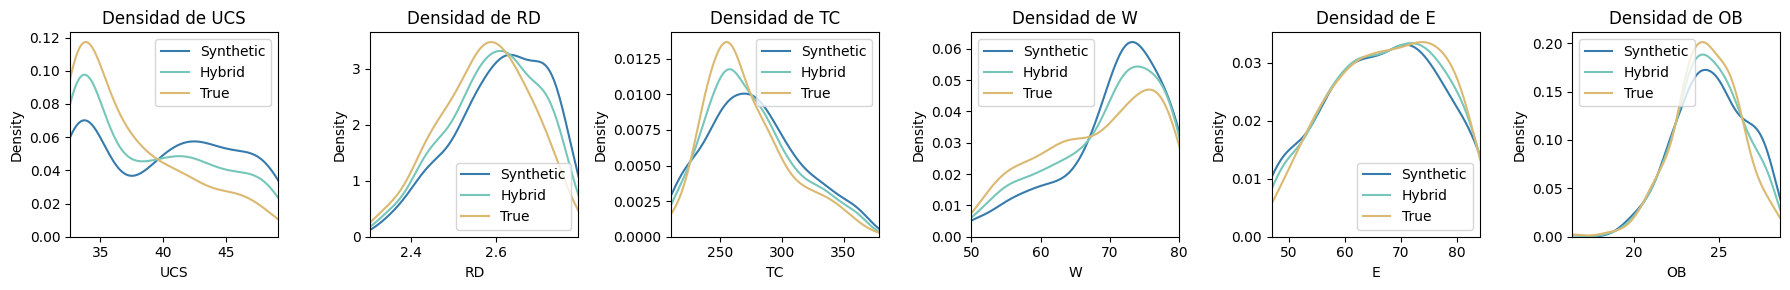

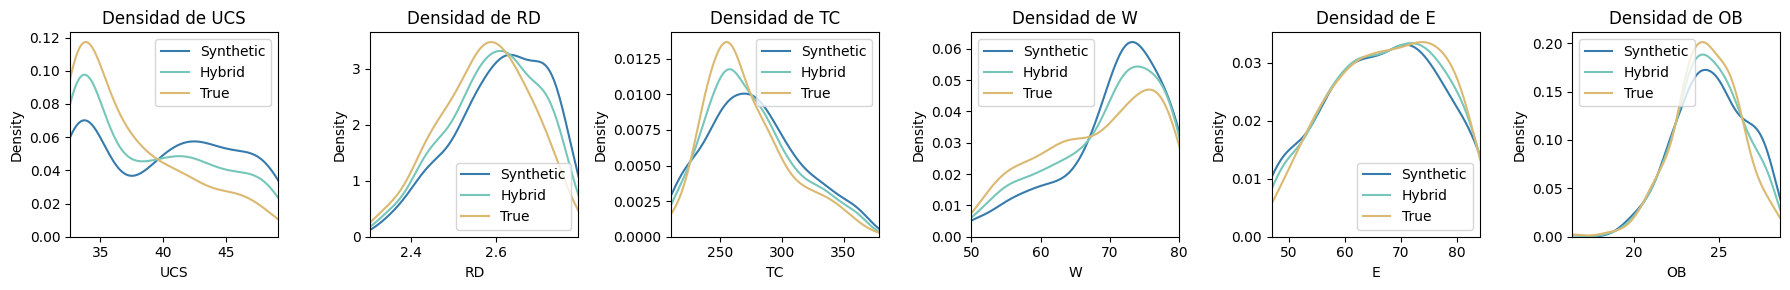

In [25]:
kernel_chart_total(df_real_train_exp2, df_synthetic_train_exp2, df_hybrid_train_exp2)

In [26]:
qc_univariate(df_real_train_exp2, df_synthetic_train_exp2)

,variable,KS_stat,KS_p,min_df_real,min_df_syn,max_df_real,max_df_syn,mean_df_real,mean_df_syn,std_df_real,std_df_syn,Δmean_%,Δstd_%
4,E,0.051482,8.029971e-01,47.000000,48.000000,84.000000,84.000000,67.693662,66.820261,9.519619,10.101309,1.290225,6.110436
5,OB,0.118337,2.895642e-02,16.344658,19.119916,28.626925,28.510230,24.281126,24.581849,1.928237,2.084974,1.238507,8.128488
1,RD,0.172006,2.725622e-04,2.304505,2.317425,2.795202,2.795202,2.574801,2.613379,0.106088,0.109147,1.498262,2.883146
2,TC,0.135276,8.007903e-03,210.361040,210.361040,378.446298,363.155538,271.747067,278.035881,33.672233,38.117245,2.314216,13.200824
0,UCS,0.290942,1.641549e-11,32.600449,32.600449,49.126658,49.126658,37.436299,40.229680,4.565022,5.495639,7.461692,20.385808
3,W,0.172903,2.488978e-04,50.000000,50.000000,80.000000,80.000000,68.348592,70.506536,8.326485,7.435953,3.157262,10.695170


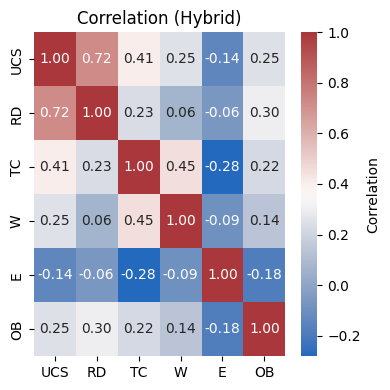

In [27]:
corr_matrix = df_hybrid_train_exp2.corr()

fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='vlag', cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation (Hybrid)')

output_path = os.path.join(out_dir_exp2, "corr_hyb.png")
plt.savefig(output_path)

plt.tight_layout()
plt.show()

C:\Users\llame\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



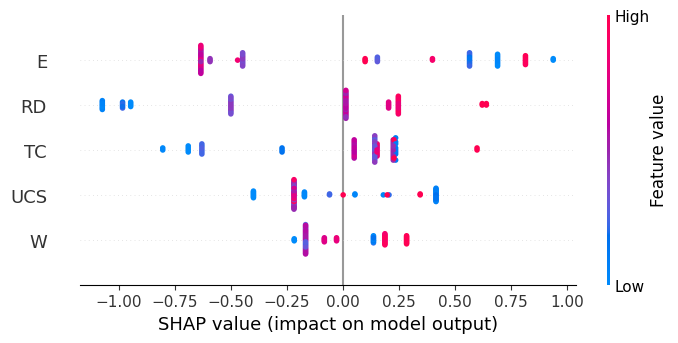

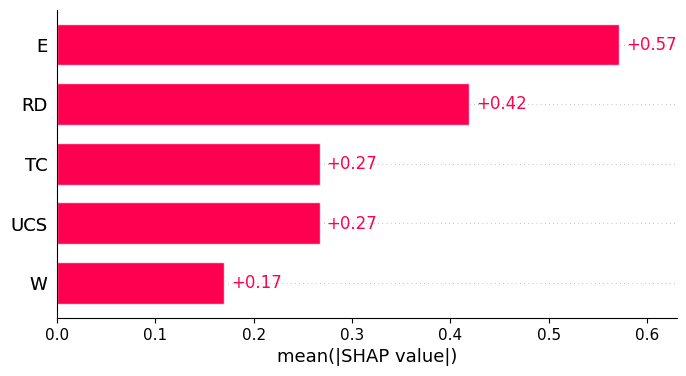

,DA-XGB,XGB,RF,DNN
R2,0.499,0.859,0.729,0.620
RMSE,1.603,0.849,1.179,1.396
MAE,1.185,0.613,0.801,0.965
MAPE,0.050,0.027,0.035,0.042


In [28]:
df_kpi_exp2, best_params_exp2, preds_exp2, shap_rank_exp2 = run_experiment(df_train = df_real_train_exp2, 
                                                           df_test = df_test, 
                                                           df_hybrid_train = df_hybrid_train_exp2,
                                                           seed = seed
                                                          )

df_kpi_exp2

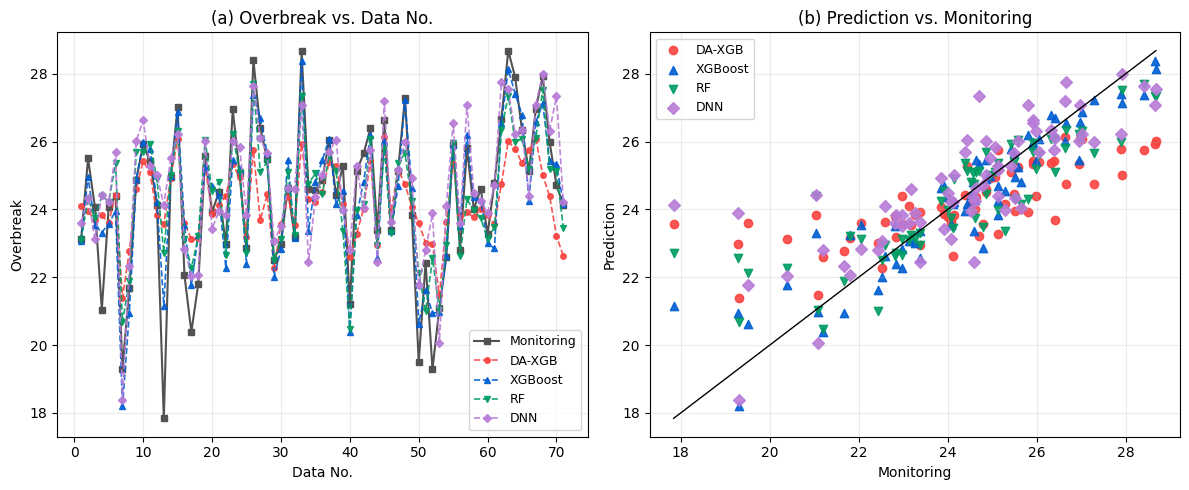

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': '(a) Overbreak vs. Data No.'}, xlabel='Data No.', ylabel='Overbreak'>,
        <Axes: title={'center': '(b) Prediction vs. Monitoring'}, xlabel='Monitoring', ylabel='Prediction'>],
       dtype=object))

In [29]:
plot_overbreak_comparison(df_test = df_test, preds_dict= preds_exp2)

In [30]:
best_params_exp2

{'DA-XGB': {'max_depth': 1, 'min_child_weight': 10, 'n_estimators': 120},
 'XGB': {'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200},
 'RF': {'max_depth': 10, 'n_estimators': 300},
 'DNN': {'dnn__activation': 'relu',
  'dnn__batch_size': 16,
  'dnn__hidden_layer_sizes': (256, 128),
  'dnn__max_iter': 190}}

In [31]:
shap_rank_exp2

,feature,mean_abs_shap
4,E,0.571654
1,RD,0.419208
2,TC,0.267411
0,UCS,0.267091
3,W,0.170238


In [32]:
# Considering the total data generated in exp2
x0_exp2 = 124
x1_exp2 = 182

# Cross validation
cv_exp2 = cv5(df_train= df_real_train_exp2,
    best_params = best_params_exp2,
    best_params_model_c0 = params_c0, 
    best_params_model_c1 = params_c1, 
    n0_sample=x0_exp2, 
    n1_sample=x1_exp2, 
    seed=seed)

C:\Users\llame\AppData\Local\Programs\Python\Python312\Lib\site-packages\sdv\single_table\base.py:168: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

C:\Users\llame\AppData\Local\Programs\Python\Python312\Lib\site-packages\sdv\single_table\base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.

C:\Users\llame\AppData\Local\Programs\Python\Python312\Lib\site-packages\ctgan\synthesizers\_utils.py:16: FutureWarning:

`cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.

Gen. (-1.53) | Discrim. (0.08): 100%|██████████████████████████████████████████████| 1000/1000 [00:27<00:00, 36.81it/s]
C:\Users\llame\AppData\Local\Programs\Python\Python312\Lib\site-packages\sdv\single_table\base.py:168: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.


In [33]:
cv_exp2

,R2_mean,R2_std,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MAPE_mean,MAPE_std
Model,,,,,,,,
XGB,0.761,0.069,0.916,0.061,0.671,0.035,0.029,0.001
RF,0.638,0.072,1.135,0.076,0.850,0.058,0.036,0.003
DNN,0.528,0.123,1.290,0.057,1.017,0.056,0.043,0.002
DA-XGB,0.553,0.107,1.261,0.135,0.933,0.094,0.040,0.004


### Sensitivity analysis

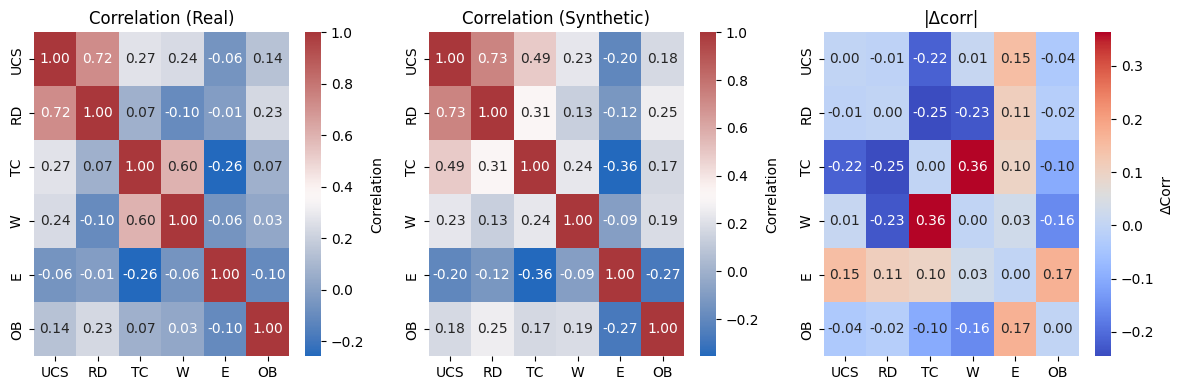

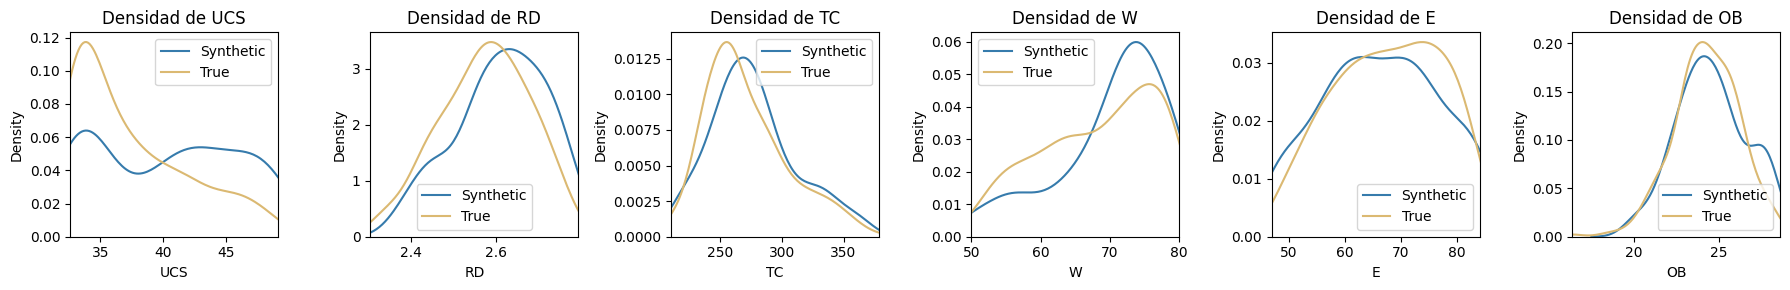

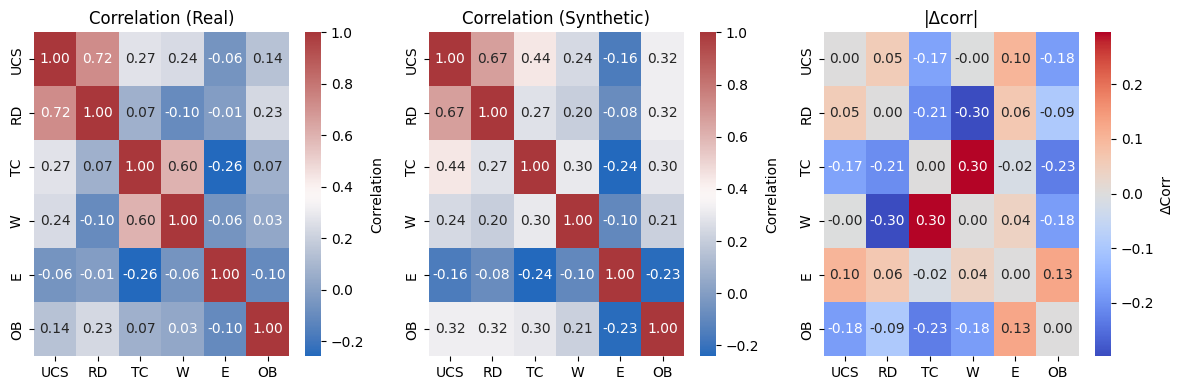

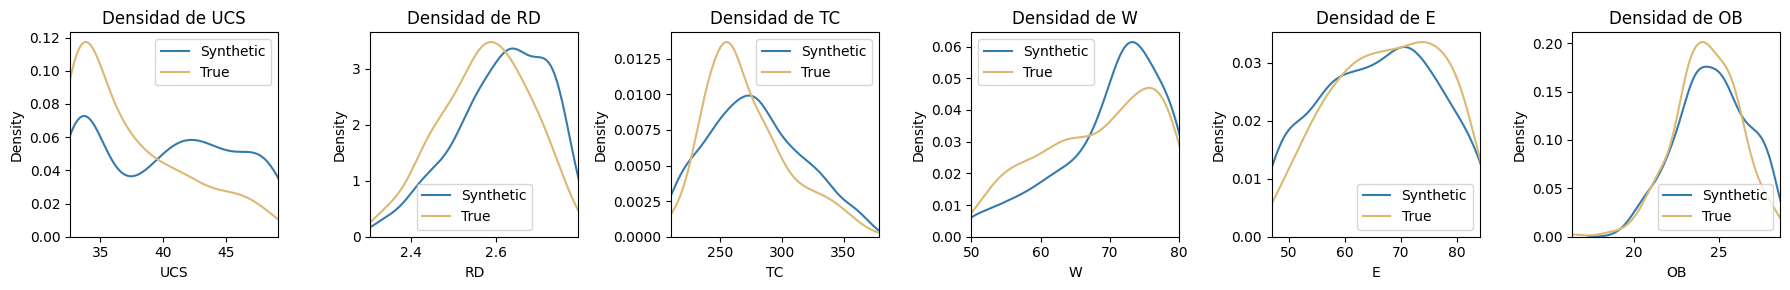

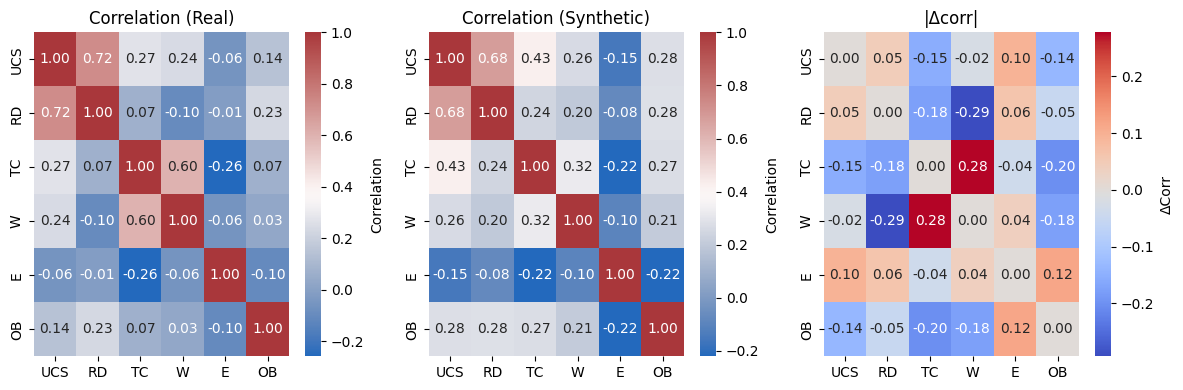

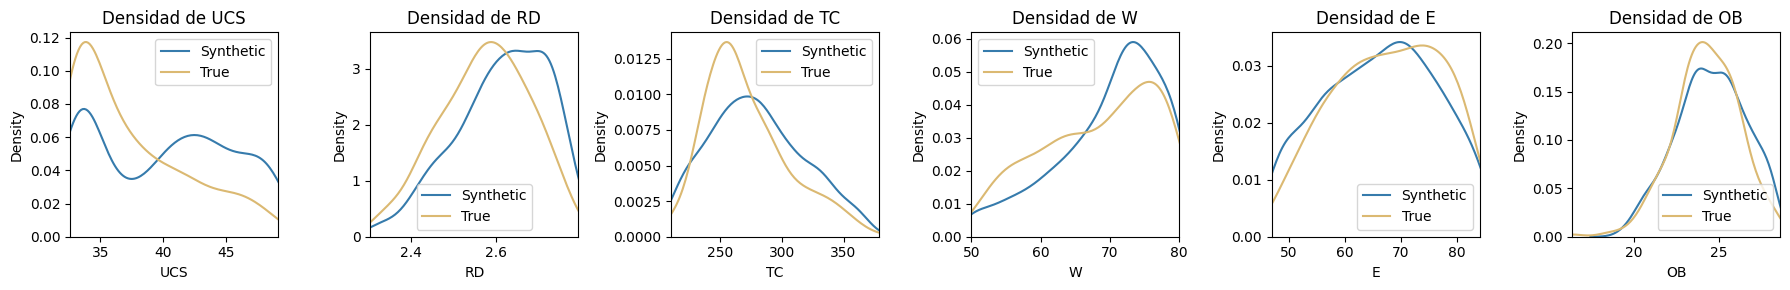

In [34]:
# Factor of augmentation
k = [50, 150, 200]

for mult in k:
    # Synthetic data
    out_dir_c0 = "2_CGTAN/ctgan_tuning/c0/best_model/exp2"
    new_c0_exp2 = pd.read_csv(PROJECT_ROOT/out_dir_c0/f'synthetic_exp2_{mult}.csv')

    out_dir_c1 = "2_CGTAN/ctgan_tuning/c1/best_model/exp2"
    new_c1_exp2 = pd.read_csv(PROJECT_ROOT/out_dir_c1/f'synthetic_exp2_{mult}.csv')
    
    # Hybrid data
    df_real_train_exp2, df_synthetic_train_exp2, df_hybrid_train_exp2 = concat_dataframe(df_c0_train= df_c0_train, 
                                                                                         df_c1_train= df_c1_train,
                                                                                         df_c0_synthetic= new_c0_exp2, 
                                                                                         df_c1_synthetic= new_c1_exp2)

    # Save
    out_dir_exp2 = "3_Sample/exp2"
    evaluate_and_merge(df_real_train_exp2, df_synthetic_train_exp2, out_dir_exp2)
    
    path_exp2 = os.path.join(out_dir_exp2, f'hybrid_exp2_{mult}.csv')
    df_hybrid_train_exp2.to_csv(path_exp2, index=False)

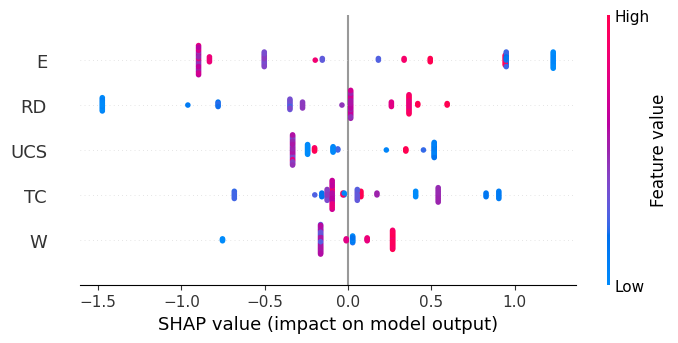

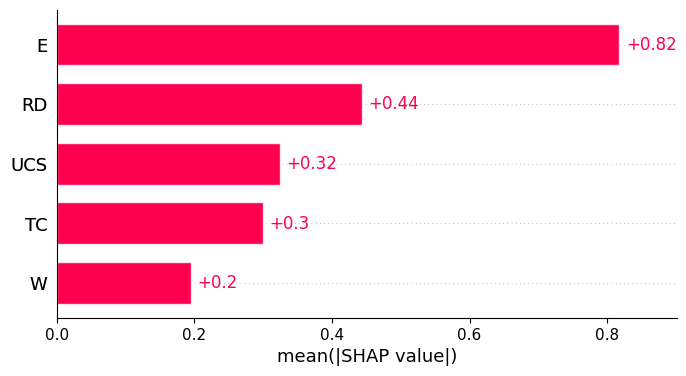

In [35]:
out_dir = "3_Models/3_Sample/exp2"
df_hybrid_train_50 = pd.read_csv(PROJECT_ROOT/out_dir/f'hybrid_exp2_50.csv')
df_hybrid_train_150 = pd.read_csv(PROJECT_ROOT/out_dir/f'hybrid_exp2_150.csv')
df_hybrid_train_200 = pd.read_csv(PROJECT_ROOT/out_dir/f'hybrid_exp2_200.csv')

# Run experiments
df_kpi_exp2_50, best_params_exp2_50, preds_exp2_50, shap_rank_exp2_50 = run_experiment(df_train = df_real_train_exp2, 
                                                                                       df_test = df_test, 
                                                                                       df_hybrid_train = df_hybrid_train_50,
                                                                                       seed = seed
                                                                                      )

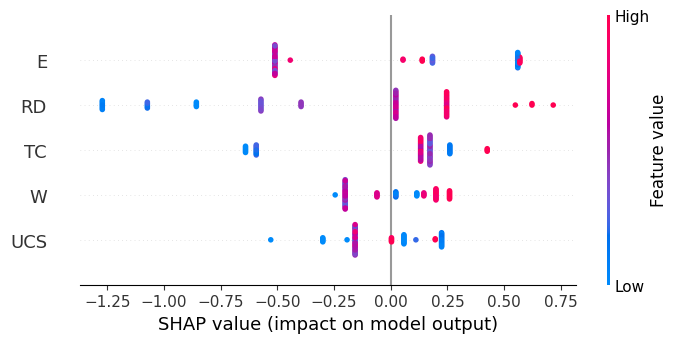

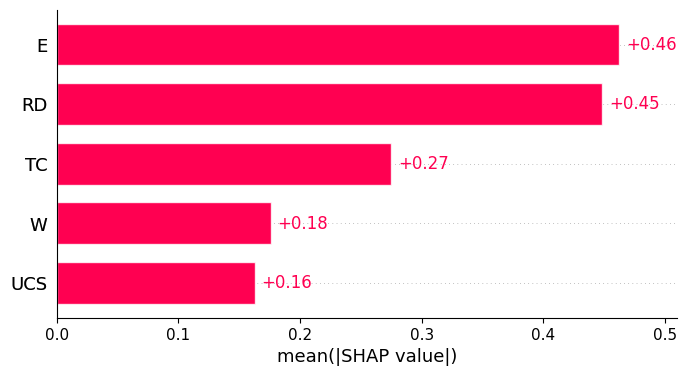

In [36]:
df_kpi_exp2_150, best_params_exp2_150, preds_exp2_150, shap_rank_exp2_150 = run_experiment(df_train = df_real_train_exp2, 
                                                                                       df_test = df_test, 
                                                                                       df_hybrid_train = df_hybrid_train_150,
                                                                                       seed = seed
                                                                                      )

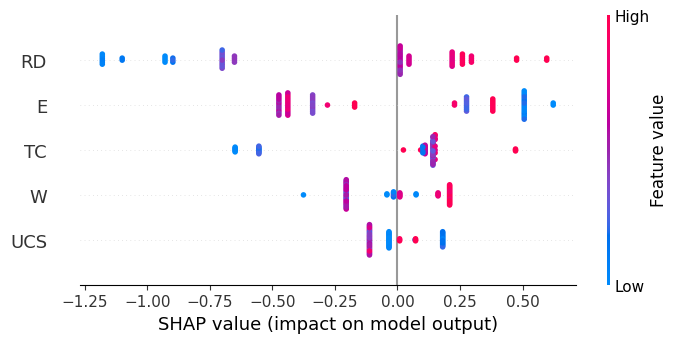

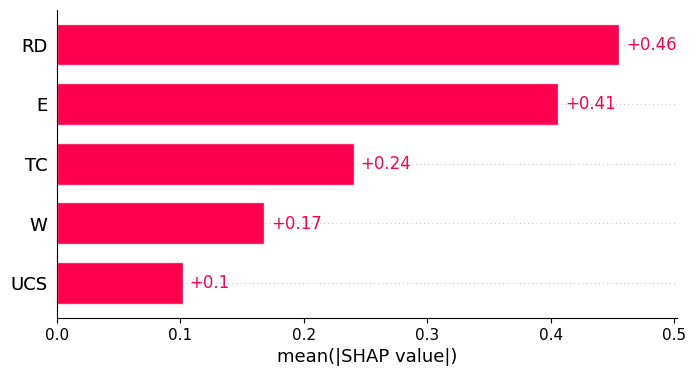

In [37]:
df_kpi_exp2_200, best_params_exp2_200, preds_exp2_200, shap_rank_exp2_200 = run_experiment(df_train = df_real_train_exp2, 
                                                                                       df_test = df_test, 
                                                                                       df_hybrid_train = df_hybrid_train_200,
                                                                                       seed = seed
                                                                                      )

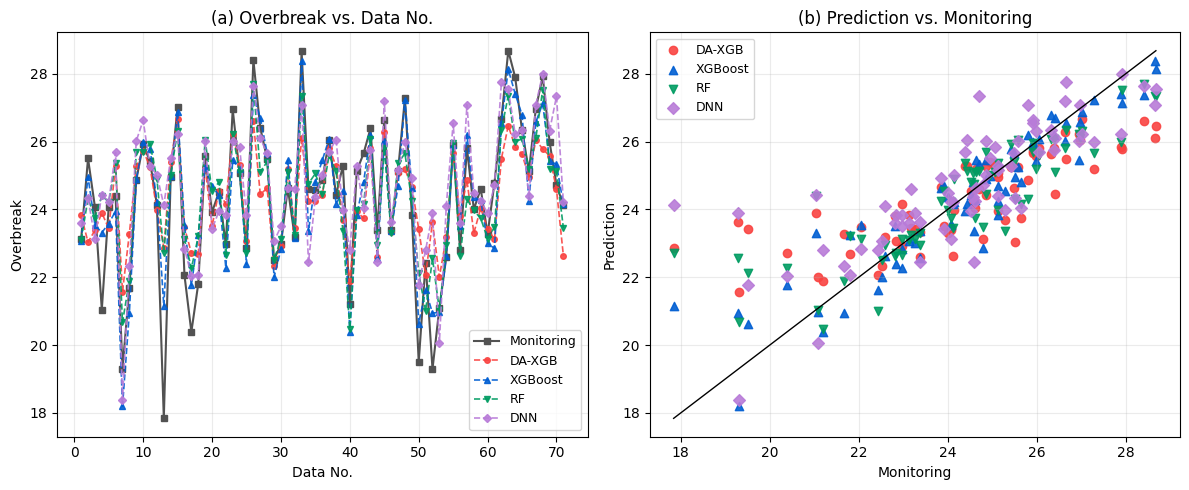

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': '(a) Overbreak vs. Data No.'}, xlabel='Data No.', ylabel='Overbreak'>,
        <Axes: title={'center': '(b) Prediction vs. Monitoring'}, xlabel='Monitoring', ylabel='Prediction'>],
       dtype=object))

In [38]:
plot_overbreak_comparison(df_test = df_test, preds_dict= preds_exp2_50)

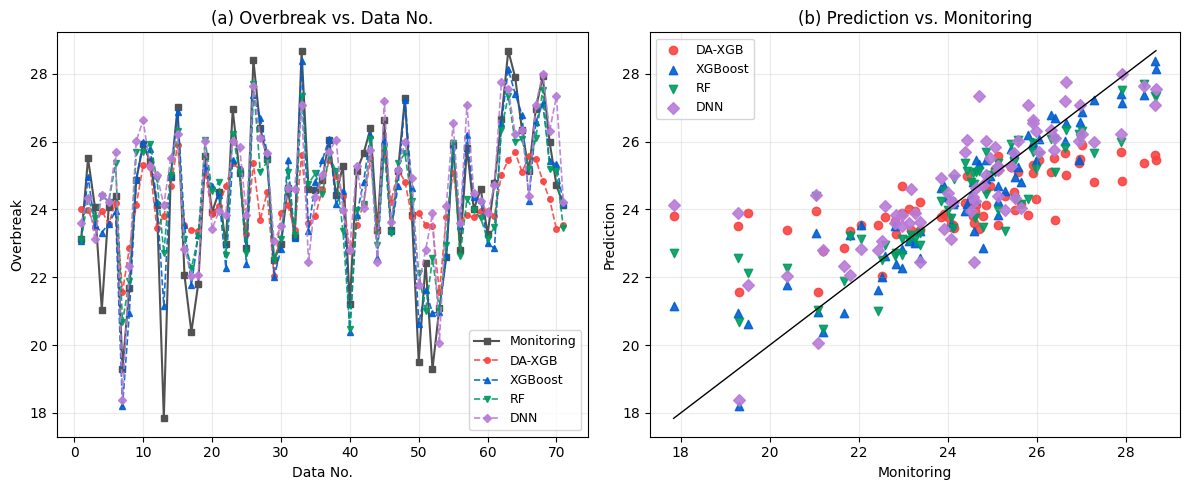

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': '(a) Overbreak vs. Data No.'}, xlabel='Data No.', ylabel='Overbreak'>,
        <Axes: title={'center': '(b) Prediction vs. Monitoring'}, xlabel='Monitoring', ylabel='Prediction'>],
       dtype=object))

In [39]:
plot_overbreak_comparison(df_test = df_test, preds_dict= preds_exp2_150)

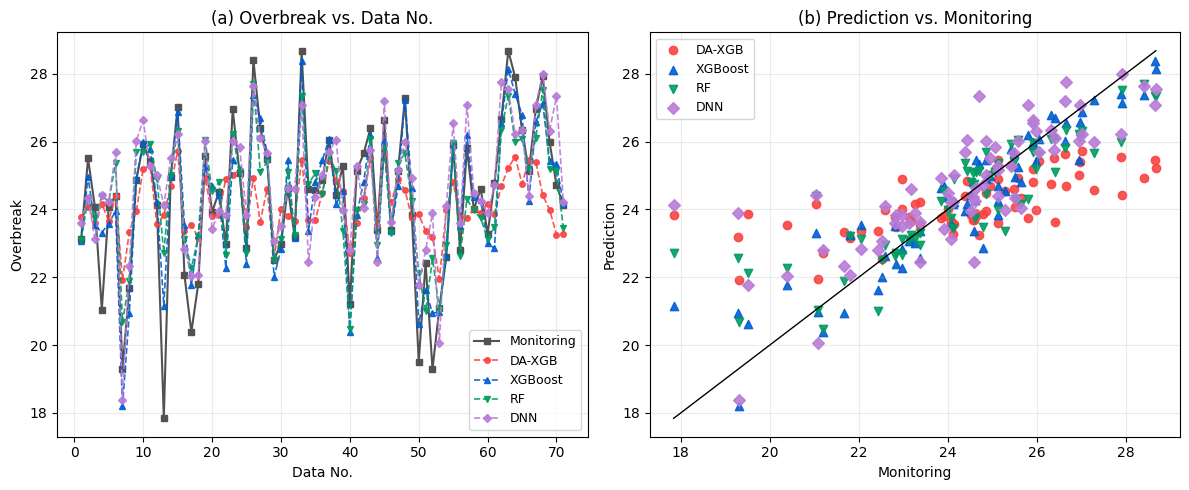

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': '(a) Overbreak vs. Data No.'}, xlabel='Data No.', ylabel='Overbreak'>,
        <Axes: title={'center': '(b) Prediction vs. Monitoring'}, xlabel='Monitoring', ylabel='Prediction'>],
       dtype=object))

In [40]:
plot_overbreak_comparison(df_test = df_test, preds_dict= preds_exp2_200)

In [41]:
dfs_shap = [shap_rank_exp1, shap_rank_exp2_50, shap_rank_exp2, shap_rank_exp2_150, shap_rank_exp2_200]
dfs_kpi = [df_kpi_exp1, df_kpi_exp2_50, df_kpi_exp2, df_kpi_exp2_150, df_kpi_exp2_200]
names = ['exp1', 'exp2_50', 'exp2_100', 'exp2_150', 'exp2_200']

for name, shap, kpi in zip(names, dfs_shap, dfs_kpi):
    shap.columns = [f"{col}_{name}" for col in shap.columns]
    kpi.columns  = [f"{col}_{name}" for col in kpi.columns]

In [42]:
shap_rank_final = pd.concat(dfs_shap, axis=1)
shap_rank_final = shap_rank_final.drop(["feature_exp2_50", "feature_exp2_100", "feature_exp2_150", "feature_exp2_200"], axis=1)
shap_rank_final.rename(columns={'feature_exp1': 'feature',
                                'mean_abs_shap_exp1': 'Exp 1', 
                                'mean_abs_shap_exp2_50': 'Exp 2 (m = 0.5)', 
                                'mean_abs_shap_exp2_100': 'Exp 2 (m = 1)',  
                                'mean_abs_shap_exp2_150': 'Exp 2 (m = 1.5)', 
                                'mean_abs_shap_exp2_200': 'Exp 2 (m = 2)'
                               }, inplace=True)

shap_rank_paper = pd.DataFrame(data = {
    'feature': ['E', 'TC', 'UCS', 'RD', 'W'],
    'Report': [1.63, 0.63, 0.51, 0.33, 0.32]})
shap_rank_final = shap_rank_paper.merge(shap_rank_final, on='feature')

shap_rank_final

,feature,Report,Exp 1,Exp 2 (m = 0.5),Exp 2 (m = 1),Exp 2 (m = 1.5),Exp 2 (m = 2)
0,E,1.63,0.319469,0.817474,0.571654,0.462312,0.406006
1,TC,0.63,0.217767,0.298965,0.267411,0.274825,0.240458
2,UCS,0.51,0.111491,0.324356,0.267091,0.162860,0.102038
3,RD,0.33,0.384306,0.443755,0.419208,0.448534,0.455241
4,W,0.32,0.197609,0.195170,0.170238,0.175846,0.167815


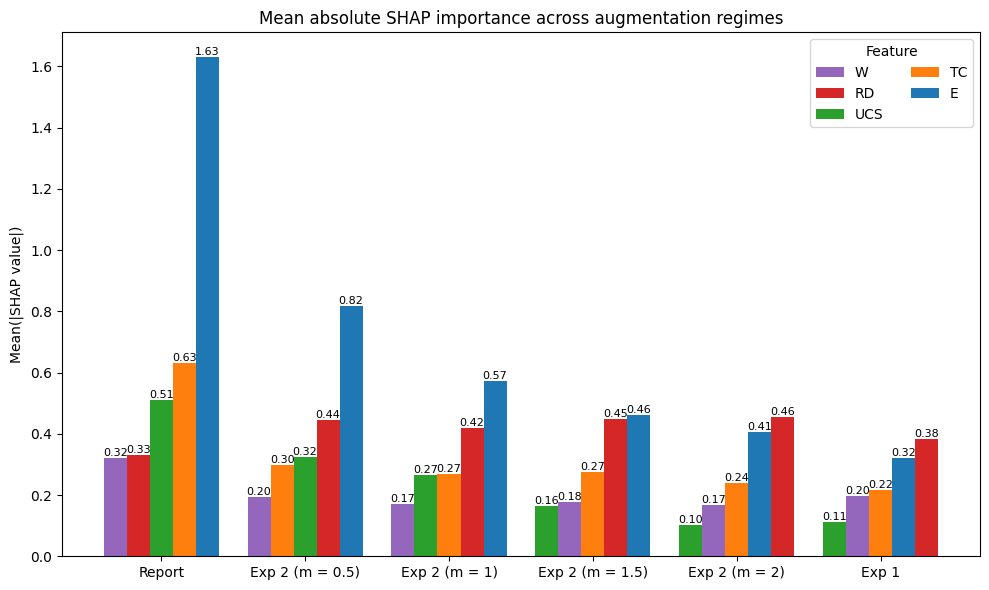

In [43]:
data = shap_rank_final.set_index("feature")
data_t = data.T

# Order de experimentos
orden = ['Report', 'Exp 2 (m = 0.5)', 'Exp 2 (m = 1)', 'Exp 2 (m = 1.5)', 'Exp 2 (m = 2)', 'Exp 1']
data_t = data_t.reindex(orden)

# (opcional) mantener el set/orden de features basado en Report
feature_order = data.loc[:, "Report"].sort_values(ascending=False).index
data_t = data_t[feature_order]

experiments = list(data_t.index)
features = list(data_t.columns)

n_exp = len(experiments)
n_feat = len(features)

x = np.arange(n_exp)
bar_width = 0.8 / n_feat

fig, ax = plt.subplots(figsize=(10, 6))

# color fijo por feature
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
feat_color = {feat: cycle[i % len(cycle)] for i, feat in enumerate(features)}

# para no repetir labels en la leyenda
legend_done = set()

for j, exp in enumerate(experiments):
    s = data_t.loc[exp].astype(float)

    # ordenar dentro del experimento (menor -> mayor)
    s_sorted = s.sort_values(ascending=True)   # index=feature, values=SHAP
    feats_sorted = list(s_sorted.index)
    vals_sorted = s_sorted.values

    for i, (feat, val) in enumerate(zip(feats_sorted, vals_sorted)):
        label = feat if feat not in legend_done else None
        b = ax.bar(
            x[j] + i * bar_width,
            val,
            width=bar_width,
            color=feat_color[feat],
            label=label
        )
        legend_done.add(feat)

        """
        # etiqueta con NOMBRE de feature (para ver el orden) + valor
        ax.text(
            x[j] + i * bar_width,
            val,
            f"{feat}\n{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )"""

        # etiqueta solo con el número (valor)
        ax.text(
            x[j] + i * bar_width,
            val,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_xticks(x + bar_width * (n_feat - 1) / 2)
ax.set_xticklabels(experiments)

ax.set_ylabel("Mean(|SHAP value|)")
ax.set_title("Mean absolute SHAP importance across augmentation regimes")
ax.legend(title="Feature", loc="best", ncol=2)

out_dir = "3_Sample"
output_path = os.path.join(out_dir, "shap.png")
plt.savefig(output_path)

plt.tight_layout()
plt.show()

In [44]:
kpi_final = pd.concat(dfs_kpi, axis=1)
kpi_final = kpi_final.drop(['RF_exp1', 'DNN_exp1', 
                            'XGB_exp2_50', 'RF_exp2_50', 'DNN_exp2_50',
                            'XGB_exp2_100', 'RF_exp2_100', 'DNN_exp2_100', 
                            'XGB_exp2_150', 'RF_exp2_150', 'DNN_exp2_150',
                            'XGB_exp2_200', 'RF_exp2_200', 'DNN_exp2_200'], axis=1)
kpi_final

,DA-XGB_exp1,XGB_exp1,DA-XGB_exp2_50,DA-XGB_exp2_100,DA-XGB_exp2_150,DA-XGB_exp2_200
R2,0.283,0.859,0.586,0.499,0.429,0.375
RMSE,1.917,0.849,1.458,1.603,1.711,1.790
MAE,1.480,0.613,1.043,1.185,1.280,1.354
MAPE,0.063,0.027,0.045,0.050,0.055,0.057


In [45]:
# Line chart data
df_kpi = kpi_final[['XGB_exp1', 'DA-XGB_exp2_50', 'DA-XGB_exp2_100',
       'DA-XGB_exp2_150', 'DA-XGB_exp2_200', 'DA-XGB_exp1']].copy()
df_kpi = df_kpi.T
df_kpi = df_kpi.rename(index={'DA-XGB_exp1': 'Exp 1',
                              'XGB_exp1': 'Baseline',
                              'DA-XGB_exp2_50': 'Exp 2 (m = 0.5)',
                              'DA-XGB_exp2_100': 'Exp 2 (m = 1)',
                              'DA-XGB_exp2_150': 'Exp 2 (m = 1.5)',
                              'DA-XGB_exp2_200': 'Exp 2 (m = 2)'})
df_kpi

,R2,RMSE,MAE,MAPE
Baseline,0.859,0.849,0.613,0.027
Exp 2 (m = 0.5),0.586,1.458,1.043,0.045
Exp 2 (m = 1),0.499,1.603,1.185,0.050
Exp 2 (m = 1.5),0.429,1.711,1.280,0.055
Exp 2 (m = 2),0.375,1.790,1.354,0.057
Exp 1,0.283,1.917,1.480,0.063


In [46]:
df_t5

,KPI,DA-XGB,XGBoost,RF,DNN
0,R2,0.883,0.782,0.739,0.764
1,RMSE,1.335,1.822,1.990,1.892
2,MAE,1.124,1.225,1.561,1.335
3,MAPE,0.050,0.051,0.076,0.060


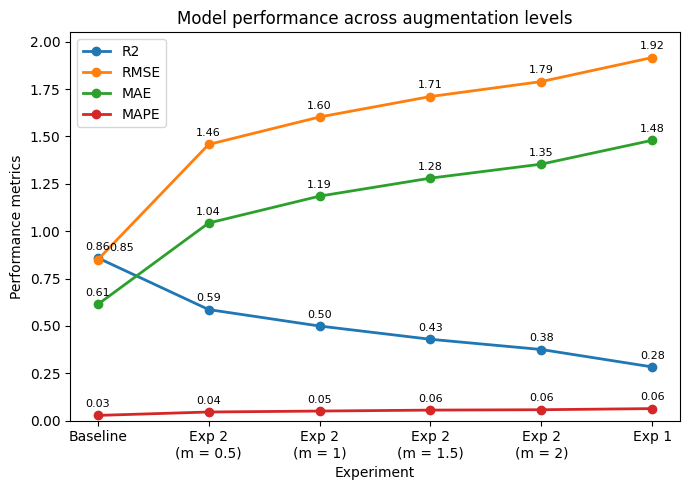

In [47]:
x = df_kpi.index
fig, ax = plt.subplots(figsize=(7, 5))

metrics = ["R2", "RMSE", "MAE", "MAPE"]

for metric in metrics:
    y = df_kpi[metric]
    ax.plot(x, y, marker='o', linewidth=2, label=metric)
    for i, (xi, yi) in enumerate(zip(x, y)):
        if i == 0 and metric == "RMSE":
            ax.annotate(f"{yi:.2f}",
                        (xi, yi),
                        textcoords="offset points",
                        xytext=(8, 6),
                        ha='left',
                        fontsize=8)
        else:
            ax.annotate(f"{yi:.2f}",
                        (xi, yi),
                        textcoords="offset points",
                        xytext=(0, 6),
                        ha='center',
                        fontsize=8)

ax.set_ylabel("Performance metrics")
ax.set_xlabel("Experiment")
ax.set_title("Model performance across augmentation levels")
ax.set_ylim(0, 2.05)

labels = [
    "Baseline",
    "Exp 2\n(m = 0.5)",
    "Exp 2\n(m = 1)",
    "Exp 2\n(m = 1.5)",
    "Exp 2\n(m = 2)",
    "Exp 1"
]
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.legend()

# limits
#ax.axhline(y=0.883, color='#1f77b4', alpha=0.5, linestyle='--', linewidth=2)
#plt.text(x=4.4, y= 0.9, s="R2 = 0.883", color='#1f77b4')

"""
ax.axhline(y=1.335, color='#ff7f0e', alpha=0.5, linestyle='--', linewidth=2)
plt.text(x=4.4, y= 1.4, s="RMSE = 1.335", color='#ff7f0e')

ax.axhline(y=1.124, color='#2ca02c', alpha=0.5, linestyle='--', linewidth=2)
plt.text(x=4.4, y= 1.2, s="MAE = 1.124", color='#2ca02c')

ax.axhline(y=0.050, color='#d62728', alpha=0.5, linestyle='--', linewidth=2)
plt.text(x=4.4, y= 0.055, s="MAPE = 0.050", color='#d62728')
"""

output_path = os.path.join(out_dir, "performance2.png")
plt.savefig(output_path)

plt.tight_layout()
plt.show()

### RMSE tails

In [48]:
# Add values
df_test['XGBoost'] = preds_exp1['XGBoost']
df_test['DA-XGB_exp1'] = preds_exp1['DA-XGB']
df_test['DA-XGB_exp2_50'] = preds_exp2_50['DA-XGB']
df_test['DA-XGB_exp2_100'] = preds_exp2['DA-XGB']
df_test['DA-XGB_exp2_150'] = preds_exp2_150['DA-XGB']
df_test['DA-XGB_exp2_200'] = preds_exp2_200['DA-XGB']

df_test = df_test.rename(columns={'DA-XGB_exp1': 'Exp 1',
                              'XGBoost': 'Baseline',
                              'DA-XGB_exp2_50': 'Exp 2 (m = 0.5)',
                              'DA-XGB_exp2_100': 'Exp 2 (m = 1)',
                              'DA-XGB_exp2_150': 'Exp 2 (m = 1.5)',
                              'DA-XGB_exp2_200': 'Exp 2 (m = 2)'})

df_test

,UCS,RD,TC,W,E,OB,cluster,Baseline,Exp 1,Exp 2 (m = 0.5),Exp 2 (m = 1),Exp 2 (m = 1.5),Exp 2 (m = 2)
0,33.335103,2.465785,293.159598,79,66,23.124611,NaN,23.061226,24.170849,23.824835,24.092445,24.015459,23.789026
1,37.170789,2.661187,270.958592,50,64,25.504786,NaN,24.966810,24.418835,23.032879,23.941986,23.989723,24.075010
2,38.187335,2.673153,239.404436,57,72,24.075356,NaN,23.542925,24.201803,23.387604,23.694992,23.490757,23.604107
3,36.280435,2.652659,249.379621,61,61,21.044088,NaN,23.316629,24.056534,23.895493,23.822271,23.962858,24.165352
4,39.516800,2.509666,322.463118,76,63,24.065130,NaN,23.584723,24.876104,23.444910,23.609426,23.573992,23.671610
...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,33.610527,2.562568,266.836194,56,50,26.973269,NaN,26.577805,24.963440,26.046825,26.082703,25.486340,25.403954
67,34.695371,2.577074,278.202476,69,84,27.923708,NaN,27.124847,23.764303,25.783033,25.022053,24.841684,24.421347
68,32.924248,2.517640,276.432503,69,59,25.988283,NaN,25.433809,24.860270,25.579966,24.387175,24.302494,23.991888
69,32.660416,2.428856,229.429251,60,85,24.711733,NaN,25.328800,22.633026,24.591633,23.220095,23.415848,23.258247


q10: 21.751812362670897 and q90: 26.588650894165042


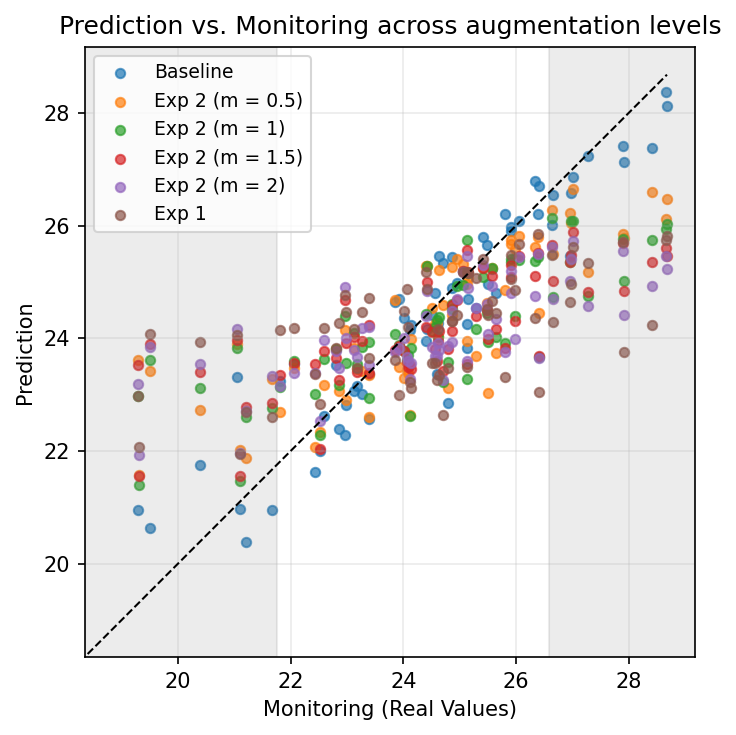

In [75]:
# Quartile
q10, q90 = np.percentile(df_real_train_exp1['OB'], [10, 90])
print("q10:", q10, "and q90:", q90)

# Chart
y_true = df_test['OB']
experiments = ['Baseline', 'Exp 2 (m = 0.5)', 'Exp 2 (m = 1)', 'Exp 2 (m = 1.5)', 'Exp 2 (m = 2)', 'Exp 1']

fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

# Scatter plots
for exp in experiments:
    y = df_test[exp]
    ax.scatter(y_true, y, label=exp, s= 20, alpha=0.7) #s, c

# y = x
all_preds = df_test[experiments].values.flatten()
vmin = min(np.nanmin(y_true), np.nanmin(all_preds))
vmax = max(np.nanmax(y_true), np.nanmax(all_preds))
ax.plot([vmin, vmax], [vmin, vmax], 'k--', linewidth=1)

# q10, q90
ax.axvspan(np.nanmin(y_true) + 0.5, q10, color='gray', alpha=0.15) #, label="q10 region")
ax.axvspan(q90, np.nanmax(y_true) + 0.5, color='gray', alpha=0.15) #, label="q90 region")

# Set limits
ax.set_xlim(vmin + 0.5, vmax + 0.5)
ax.set_ylim(vmin + 0.5, vmax + 0.5)
ax.set_aspect('equal', adjustable='box')

ax.set_xlabel('Monitoring (Real Values)')
ax.set_ylabel('Prediction')
ax.set_title('Prediction vs. Monitoring across augmentation levels')

ax.grid(True, alpha=0.25)
ax.legend(loc='upper left', fontsize=9)

output_path = os.path.join(out_dir, "teil.png")
plt.savefig(output_path)

plt.tight_layout()
plt.show()

In [68]:
# filter test data
df_test_q10 = df_test[df_test['OB'] <= q10]
df_test_q90 = df_test[df_test['OB'] >= q90]

columns = ['Baseline', 'Exp 1', 'Exp 2 (m = 0.5)', 'Exp 2 (m = 1)', 'Exp 2 (m = 1.5)', 'Exp 2 (m = 2)']
rmse_tails = pd.DataFrame(columns=["RMSE q10", "RMSE q90"], index=columns)

rmse_q10 = []
rmse_q90 = []
for column in columns:
    rmse_q10.append(root_mean_squared_error(df_test_q10['OB'], df_test_q10[column]))
    rmse_q90.append(root_mean_squared_error(df_test_q90['OB'], df_test_q90[column]))
rmse_tails["RMSE q10"] = rmse_q10
rmse_tails["RMSE q90"] = rmse_q90

kpi = df_kpi.merge(rmse_tails, left_index=True, right_index=True).copy()
kpi = kpi[['RMSE q10', 'RMSE', 'RMSE q90']]
kpi

,UCS,RD,TC,W,E,OB,cluster,Baseline,Exp 1,Exp 2 (m = 0.5),Exp 2 (m = 1),Exp 2 (m = 1.5),Exp 2 (m = 2)
3,36.280435,2.652659,249.379621,61,61,21.044088,NaN,23.316629,24.056534,23.895493,23.822271,23.962858,24.165352
6,32.625278,2.378824,221.670774,70,66,19.304501,NaN,18.190184,22.070107,21.579699,21.397146,21.558323,21.923399
7,32.600009,2.358192,234.416843,73,78,21.675417,NaN,20.955856,22.610374,23.284813,22.770855,22.853182,23.332430
12,43.129573,2.529019,268.221636,64,67,17.839203,NaN,21.154259,24.161512,22.877340,23.571556,23.809828,23.826138
16,38.603896,2.625191,244.392028,73,66,20.387468,NaN,21.757942,23.932119,22.718918,23.115236,23.407520,23.552397
39,32.722096,2.335728,236.910640,78,76,21.200125,NaN,20.379454,22.695049,21.877569,22.597418,22.779173,22.717657
49,43.961859,2.799168,246.885824,67,65,19.499905,NaN,20.636145,24.082867,23.425117,23.613485,23.898342,23.851267
51,32.680250,2.471535,234.416843,69,77,19.290323,NaN,20.945976,22.978813,23.621576,22.970024,23.517761,23.188377
52,32.611734,2.391006,217.146881,63,73,21.092722,NaN,20.960865,21.948790,22.008427,21.469790,21.558323,21.959110


In [71]:
cv_exp1_2 = cv_exp1[['R2_mean', 'RMSE_mean', 'MAE_mean', 'MAPE_mean']].copy()
cv_exp1_2.columns = cv_exp1_2.columns.str.replace("mean", "exp1", regex=False)
cv_exp1_2

,R2_exp1,RMSE_exp1,MAE_exp1,MAPE_exp1
Model,,,,
XGB,0.761,0.916,0.671,0.029
RF,0.638,1.135,0.850,0.036
DNN,0.528,1.290,1.017,0.043
DA-XGB,0.424,1.433,1.076,0.046
